In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

## data Load


In [5]:
!pip install tqdm

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

print("데이터 로드 중...")
df = pd.read_parquet("merged_ohlcv.parquet")
print(f"로드 완료: {df.shape[0]:,}행, {df['종목코드'].nunique()}종목, 메모리 {df.memory_usage(deep=True).sum()/1e6:.1f}MB")

df['날짜'] = pd.to_datetime(df['날짜'])
df['종목코드'] = df['종목코드'].astype('category')  # 문자열 반복 대신 카테고리로 -> groupby 훨씬 빨라짐
df = df.sort_values(['종목코드', '날짜']).reset_index(drop=True)

print("shift 연산 중...")
df['다음날_시가'] = df.groupby('종목코드', observed=True)['시가'].shift(-1)
df['다음날_날짜'] = df.groupby('종목코드', observed=True)['날짜'].shift(-1)

df['갭퍼센트'] = (df['다음날_시가'] - df['종가']) / df['종가'] * 100
print("셀 1 완료")
df.head()

데이터 로드 중...
로드 완료: 3,055,322행, 2765종목, 메모리 831.7MB
shift 연산 중...
셀 1 완료


,날짜,종목코드,종목명,시장,시가,고가,저가,종가,거래량,거래대금,다음날_시가,다음날_날짜,갭퍼센트
0,2021-07-12,000020,동화약품,KOSPI,15000,15150,14900,15050,160334,0.668896,15050.0,2021-07-13,0.000000
1,2021-07-13,000020,동화약품,KOSPI,15050,15100,14850,14850,184810,-1.328904,14950.0,2021-07-14,0.673401
2,2021-07-14,000020,동화약품,KOSPI,14950,14950,14700,14750,118825,-0.673401,15000.0,2021-07-15,1.694915
3,2021-07-15,000020,동화약품,KOSPI,15000,15000,14750,14850,149813,0.677966,14850.0,2021-07-16,0.000000
4,2021-07-16,000020,동화약품,KOSPI,14850,14950,14650,14800,169898,-0.336700,14800.0,2021-07-19,0.000000


In [2]:
df['날짜차이'] = (df['다음날_날짜'] - df['날짜']).dt.days
df_clean = df[(df['날짜차이'] <= 5) & (df['다음날_시가'].notna())].copy()  # 주말/연휴 감안 5일 이내만 인정

In [4]:
print(df.columns.tolist())

['날짜', '종목코드', '종목명', '시장', '시가', '고가', '저가', '종가', '거래량', '거래대금', '다음날_시가', '다음날_날짜', '갭퍼센트', '날짜차이']


In [5]:
df_clean['전일종가'] = df_clean.groupby('종목코드')['종가'].shift(1)
df_clean['등락률'] = (df_clean['종가'] - df_clean['전일종가']) / df_clean['전일종가'] * 100
df_clean[['날짜', '종목코드', '종목명', '전일종가', '종가', '등락률']].head(10)

C:\Users\tpdlq\AppData\Local\Temp\ipykernel_9100\3514173915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean['전일종가'] = df_clean.groupby('종목코드')['종가'].shift(1)


,날짜,종목코드,종목명,전일종가,종가,등락률
0,2021-07-12,000020,동화약품,NaN,15050,NaN
1,2021-07-13,000020,동화약품,15050.0,14850,-1.328904
2,2021-07-14,000020,동화약품,14850.0,14750,-0.673401
3,2021-07-15,000020,동화약품,14750.0,14850,0.677966
4,2021-07-16,000020,동화약품,14850.0,14800,-0.336700
5,2021-07-19,000020,동화약품,14800.0,15100,2.027027
6,2021-07-20,000020,동화약품,15100.0,14900,-1.324503
7,2021-07-21,000020,동화약품,14900.0,14800,-0.671141
8,2021-07-22,000020,동화약품,14800.0,14750,-0.337838
9,2021-07-23,000020,동화약품,14750.0,14600,-1.016949


In [6]:
thresholds = [18, 20, 23, 25, 27]
results = {}

for th in tqdm(thresholds, desc="임계값별 분석"):
    subset = df_clean[df_clean['등락률'] >= th].copy()
    subset['갭방향'] = np.where(subset['갭퍼센트'] > 0, '상승', '하락')
    subset['연월'] = subset['날짜'].dt.to_period('M')

    monthly = subset.groupby(['연월', '갭방향'], observed=True).size().unstack(fill_value=0)
    for col in ['상승', '하락']:
        if col not in monthly.columns:
            monthly[col] = 0
    monthly['전체'] = monthly['상승'] + monthly['하락']
    monthly['상승비율(%)'] = (monthly['상승'] / monthly['전체'] * 100).round(1)

    results[th] = monthly
    print(f"\n=== {th}% 이상, 케이스 수: {len(subset)} ===")

임계값별 분석:   0%|          | 0/5 [00:00<?, ?it/s]


=== 18% 이상, 케이스 수: 13246 ===

=== 20% 이상, 케이스 수: 10980 ===

=== 23% 이상, 케이스 수: 8722 ===

=== 25% 이상, 케이스 수: 7765 ===

=== 27% 이상, 케이스 수: 7047 ===


In [7]:
summary = []
for th in thresholds:
    subset = df_clean[df_clean['등락률'] >= th]
    up = (subset['갭퍼센트'] > 0).sum()
    down = (subset['갭퍼센트'] <= 0).sum()
    total = up + down
    summary.append({
        '임계값(%)': th,
        '케이스수': total,
        '갭상승': up,
        '갭하락': down,
        '갭상승비율(%)': round(up/total*100, 1) if total else None,
        '평균갭(%)': round(subset['갭퍼센트'].mean(), 2) if total else None,
    })

summary_df = pd.DataFrame(summary)
summary_df

,임계값(%),케이스수,갭상승,갭하락,갭상승비율(%),평균갭(%)
0,18,13246,7756,5490,58.6,2.85
1,20,10980,6822,4158,62.1,3.43
2,23,8722,5866,2856,67.3,4.33
3,25,7765,5476,2289,70.5,4.90
4,27,7047,5198,1849,73.8,5.50


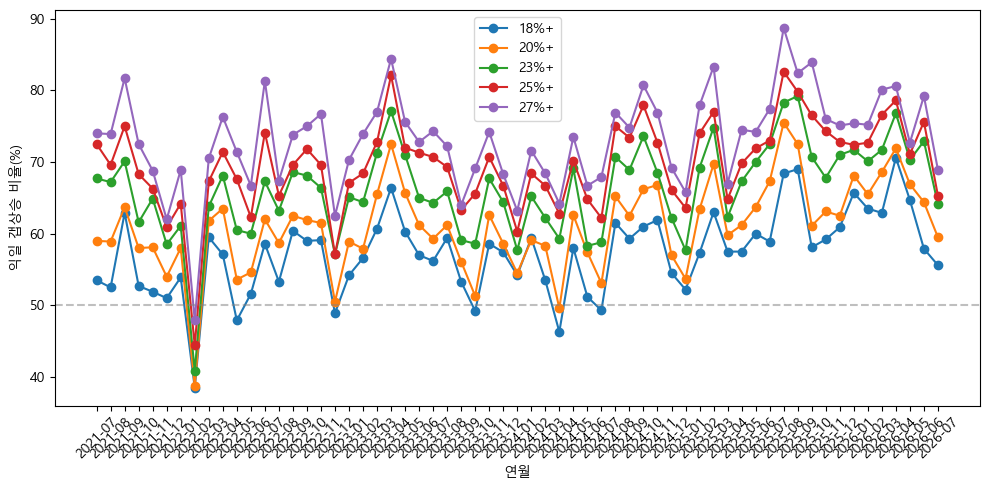

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for th in thresholds:
    monthly = results[th]
    ax.plot(monthly.index.astype(str), monthly['상승비율(%)'], marker='o', label=f'{th}%+')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('연월')
ax.set_ylabel('익일 갭상승 비율(%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 전체 거래일 리스트 (기준: df_clean에 있는 모든 날짜)
all_trading_dates = sorted(df_clean['날짜'].unique())

thresholds = [18, 20, 23, 25, 27]
daily_counts_by_threshold = {}

for th in thresholds:
    subset = df_clean[df_clean['등락률'] >= th]
    daily_count = subset.groupby('날짜').size()
    # 전체 거래일 기준으로 재구성, 없는 날은 0으로 채움
    daily_count = daily_count.reindex(all_trading_dates, fill_value=0)
    daily_counts_by_threshold[th] = daily_count

# 월 정보 붙이기
result_df = pd.DataFrame(daily_counts_by_threshold)
result_df['연월'] = pd.to_datetime(result_df.index).to_period('M')
result_df.head()

,18,20,23,25,27,연월
날짜,,,,,,
2021-07-12,0,0,0,0,0,2021-07
2021-07-13,9,7,6,4,4,2021-07
2021-07-14,7,6,4,3,3,2021-07
2021-07-15,10,7,6,5,5,2021-07
2021-07-16,6,5,4,3,2,2021-07


C:\Users\tpdlq\AppData\Local\Temp\ipykernel_9100\4043103208.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_month, labels=[str(m) for m in months])
C:\Users\tpdlq\AppData\Local\Temp\ipykernel_9100\4043103208.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_month, labels=[str(m) for m in months])
C:\Users\tpdlq\AppData\Local\Temp\ipykernel_9100\4043103208.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_month, labels=[str(m) for m in months])
C:\Users\tpdlq\AppData\Local\Temp\ipykernel_9100\4043103208.py:7: MatplotlibDeprecationWarning: The 'labels' par

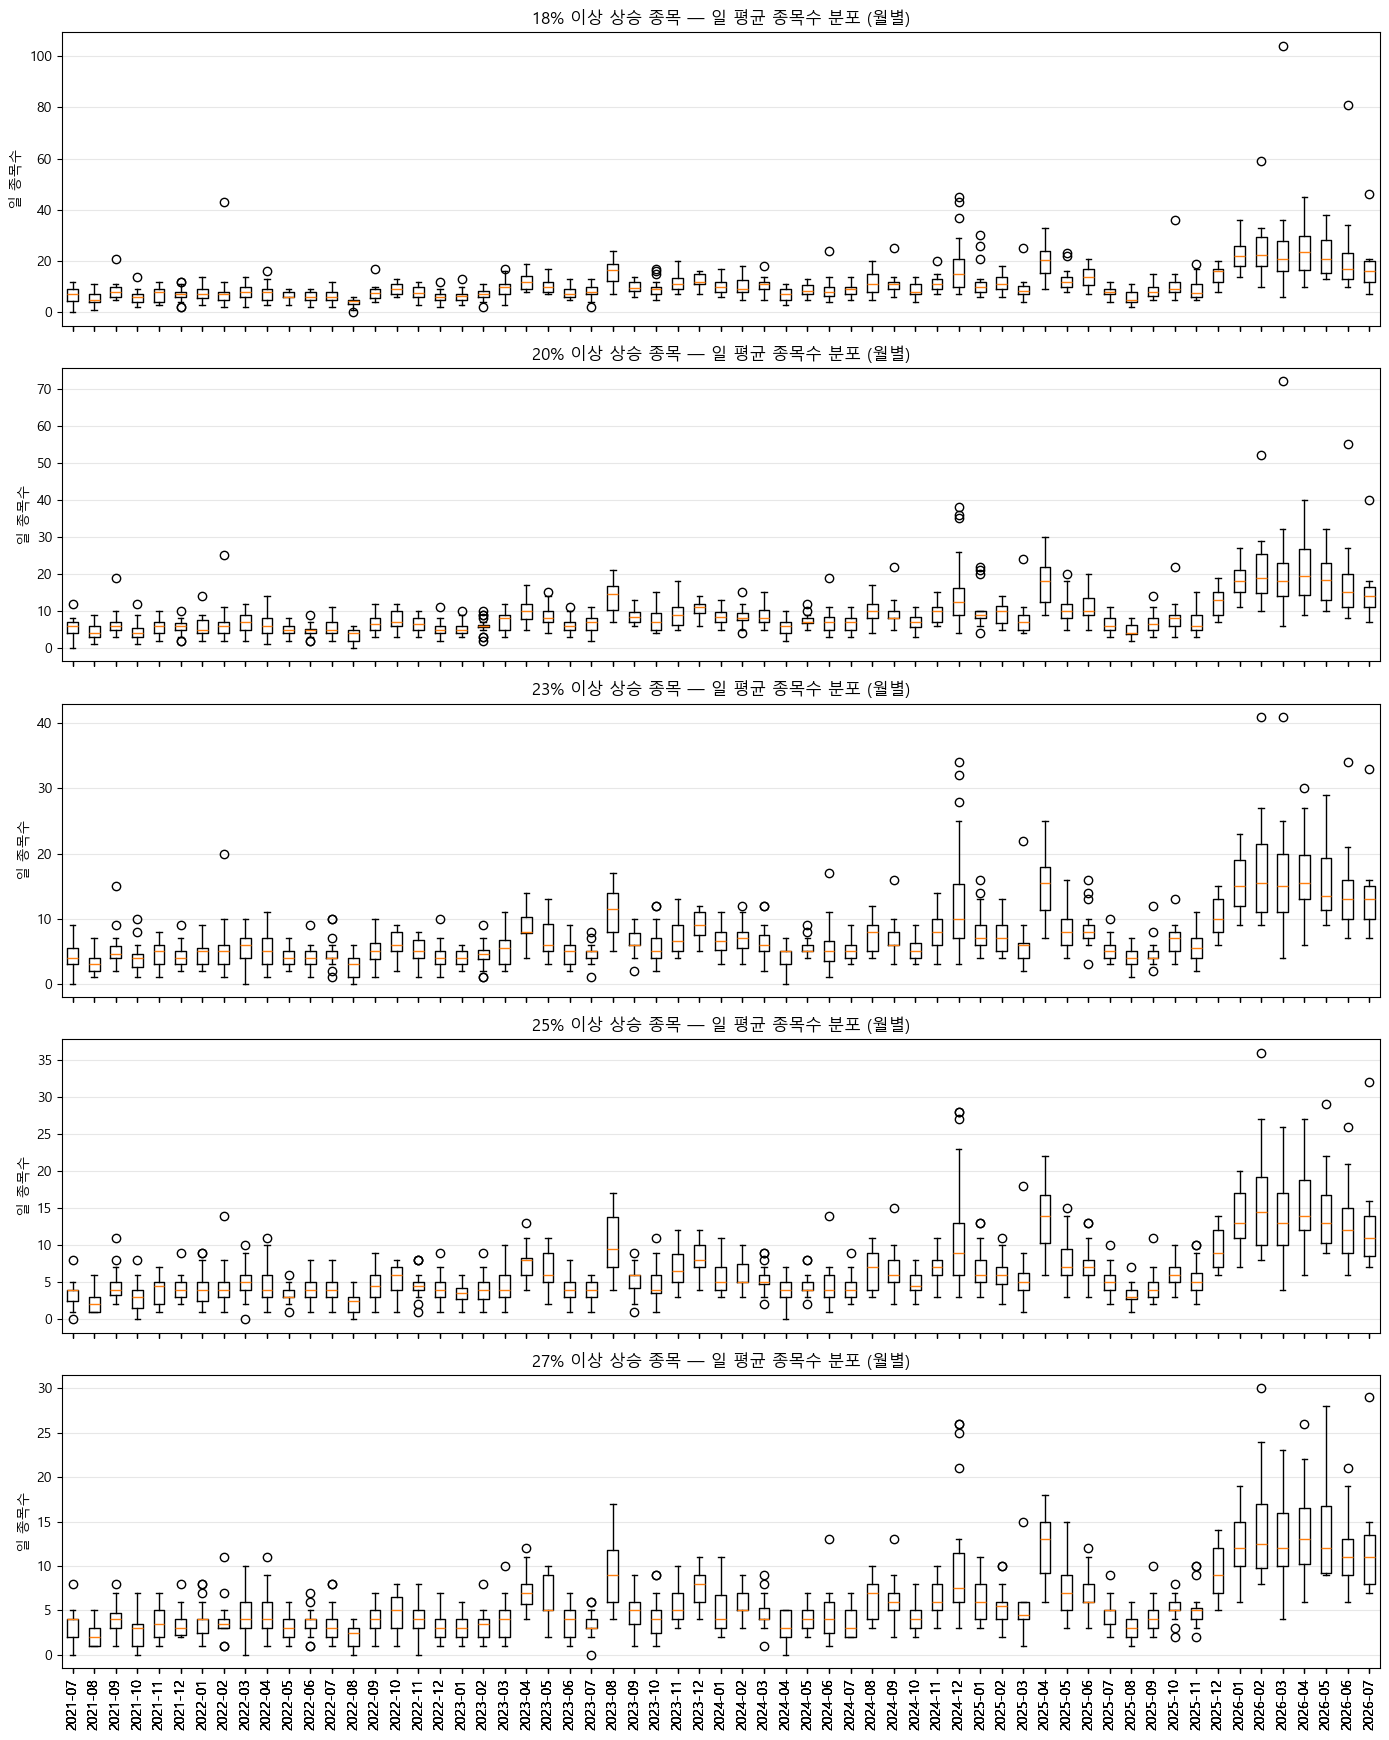

In [ ]:
fig, axes = plt.subplots(len(thresholds), 1, figsize=(14, 3.5*len(thresholds)), sharex=True)

months = sorted(result_df['연월'].unique())

for ax, th in zip(axes, thresholds):
    data_by_month = [result_df[result_df['연월'] == m][th].values for m in months]
    ax.boxplot(data_by_month, labels=[str(m) for m in months])
    ax.set_title(f'{th}% 이상 상승 종목 — 일 평균 종목수 분포 (월별)')
    ax.set_ylabel('일 종목수')
    ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

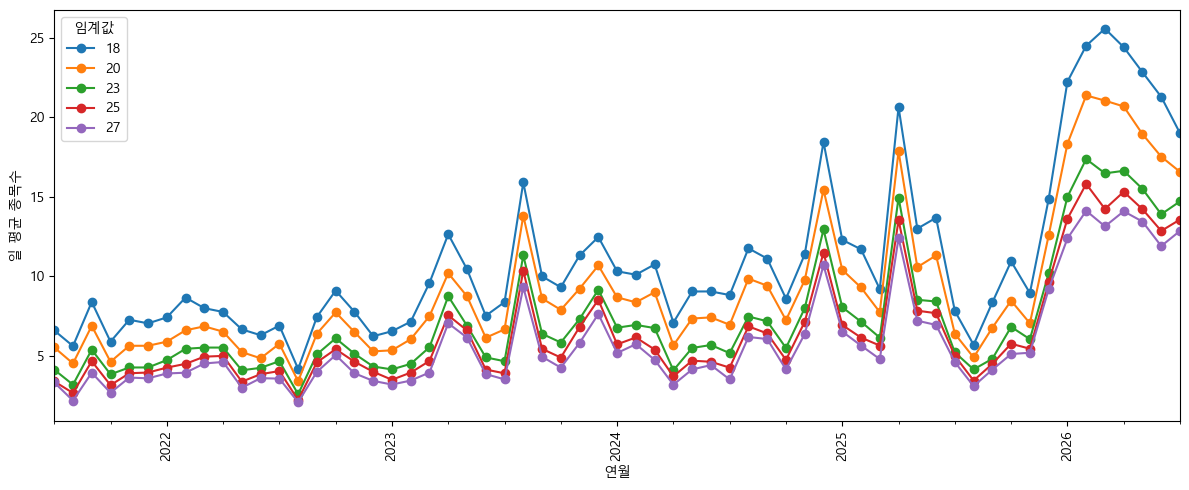

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
monthly_mean = result_df.groupby('연월')[thresholds].mean()
monthly_mean.plot(marker='o', ax=ax)
ax.set_ylabel('일 평균 종목수')
ax.legend(title='임계값')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
threshold_returns = {}

for th in thresholds:
    subset = df_clean[df_clean['등락률'] >= th].dropna(subset=['갭퍼센트']).copy()
    subset['연월'] = subset['날짜'].dt.to_period('M')
    threshold_returns[th] = subset

    overall_avg = subset['갭퍼센트'].mean()
    print(f"{th}%+ : 전체 트레이드 {len(subset)}건, 평균 수익률 {overall_avg:.3f}%")

print("\n=== 월별 평균 수익률 ===")
monthly_avg_table = pd.DataFrame({
    th: threshold_returns[th].groupby('연월')['갭퍼센트'].mean()
    for th in thresholds
})
monthly_avg_table

18%+ : 전체 트레이드 13246건, 평균 수익률 2.847%
20%+ : 전체 트레이드 10980건, 평균 수익률 3.432%
23%+ : 전체 트레이드 8722건, 평균 수익률 4.327%
25%+ : 전체 트레이드 7765건, 평균 수익률 4.898%
27%+ : 전체 트레이드 7047건, 평균 수익률 5.499%

=== 월별 평균 수익률 ===


,18,20,23,25,27
연월,,,,,
2021-07,3.044905,3.754619,5.144761,6.492964,6.670115
2021-08,2.147103,2.689730,3.945163,4.521828,5.425434
2021-09,3.540443,3.873072,4.987461,5.745369,6.728096
2021-10,1.989951,2.560458,3.124220,3.981325,4.702725
2021-11,2.586208,3.403774,4.809586,4.972776,5.371307
...,...,...,...,...,...
2026-03,3.821894,4.667368,5.564452,6.474879,7.057759
2026-04,4.301011,4.938723,6.005880,6.385236,6.926370
2026-05,3.399418,3.856196,4.499786,4.806652,5.032217


In [15]:
def monthly_cumulative_return(subset):
    """월별로 그 달 안의 모든 트레이드를 순서대로 복리 계산 (동일비중 가정)"""
    subset = subset.sort_values('날짜')
    monthly_cum = {}
    for month, group in subset.groupby('연월'):
        cum = 1.0
        for r in group['갭퍼센트']:
            cum *= (1 + r/100)
        monthly_cum[month] = (cum - 1) * 100  # %
    return pd.Series(monthly_cum)

monthly_cum_table = pd.DataFrame({
    th: monthly_cumulative_return(threshold_returns[th])
    for th in thresholds
})
monthly_cum_table

,18,20,23,25,27
2021-07,1388.926676,1558.005353,1711.930690,1957.647598,2007.480265
2021-08,921.046642,952.269468,1067.422777,955.057302,920.546635
2021-09,13007.307523,7714.229918,8156.332661,8125.852413,7856.269848
2021-10,694.930378,722.353649,748.445928,848.063710,860.692770
2021-11,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
...,...,...,...,...,...
2026-03,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
2026-04,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
2026-05,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
2026-06,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000


In [17]:
summary = []
for th in thresholds:
    subset = threshold_returns[th]
    total_cum = 1.0
    for r in subset['갭퍼센트']:
        total_cum *= (1 + r/100)
    summary.append({
        '임계값(%)': th,
        '트레이드수': len(subset),
        '평균수익률(%)': round(subset['갭퍼센트'].mean(), 3),
        '전체기간누적수익률(%)': round((total_cum - 1) * 100, 1),
    })

pd.DataFrame(summary)

,임계값(%),트레이드수,평균수익률(%),전체기간누적수익률(%)
0,18,13246,2.847,-100.0
1,20,10980,3.432,-100.0
2,23,8722,4.327,-100.0
3,25,7765,4.898,-100.0
4,27,7047,5.499,-100.0


In [20]:
from pykrx import stock
from datetime import datetime

today_str = datetime.today().strftime("%Y%m%d")
cap_df = stock.get_market_cap(today_str, market="ALL")

# 혹시 오늘이 휴장일(주말 등)이면 빈 데이터 반환될 수 있음 -> 그 경우 최근 영업일로 재시도
if cap_df.empty:
    from pykrx import stock
    recent_day = stock.get_nearest_business_day_in_a_week()  # 최근 영업일 자동 계산
    cap_df = stock.get_market_cap(recent_day, market="ALL")

shares = cap_df["상장주식수"]
shares.index = shares.index.astype(str).str.zfill(6)  # 종목코드 6자리 맞추기

df['종목코드'] = df['종목코드'].astype(str).str.zfill(6)
df['상장주식수'] = df['종목코드'].map(shares)
df['시가총액'] = df['종가'] * df['상장주식수']

df[['날짜', '종목코드', '종목명', '종가', '상장주식수', '시가총액']].head()

KRX 로그인 시도...
  로그인 ID: hard8903
KRX 로그인 완료.
  로그인 시간: 2026-07-11 14:07:18
  만료 시간: 2026-07-11 15:07:18


c:\Users\tpdlq\Documents\Code Studio\create\venv\lib\site-packages\pykrx\website\krx\market\wrap.py:249: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)


,날짜,종목코드,종목명,종가,상장주식수,시가총액
0,2021-07-12,000020,동화약품,15050,27931470,420368623500
1,2021-07-13,000020,동화약품,14850,27931470,414782329500
2,2021-07-14,000020,동화약품,14750,27931470,411989182500
3,2021-07-15,000020,동화약품,14850,27931470,414782329500
4,2021-07-16,000020,동화약품,14800,27931470,413385756000


In [24]:
target_th = 25  # 원하는 임계값으로 조정 가능
target_cases = df_clean[df_clean['등락률'] >= target_th][['종목코드', '날짜']].drop_duplicates()
print(f"대상 케이스 수: {len(target_cases)}, 고유 종목 수: {target_cases['종목코드'].nunique()}")

대상 케이스 수: 7765, 고유 종목 수: 1893


In [25]:
from pykrx import stock
from tqdm import tqdm
import pandas as pd

investor_data = []
tickers = target_cases['종목코드'].unique()

for ticker in tqdm(tickers, desc="투자자 데이터 조회"):
    dates_needed = target_cases[target_cases['종목코드'] == ticker]['날짜']
    start = dates_needed.min().strftime("%Y%m%d")
    end = dates_needed.max().strftime("%Y%m%d")

    try:
        df_inv = stock.get_market_trading_value_by_date(start, end, ticker)
        df_inv = df_inv.reset_index()
        df_inv.columns = ['날짜'] + list(df_inv.columns[1:])
        df_inv['종목코드'] = ticker
        investor_data.append(df_inv)
    except Exception as e:
        print(f"  실패: {ticker} - {e}")

investor_df = pd.concat(investor_data, ignore_index=True)
investor_df['날짜'] = pd.to_datetime(investor_df['날짜'])
print(f"수집 완료: {len(investor_df)}행")
investor_df.head()

투자자 데이터 조회: 100%|██████████| 1893/1893 [20:18<00:00,  1.55it/s]


수집 완료: 753646행


,날짜,기관합계,기타법인,개인,외국인합계,전체,종목코드
0,2024-02-21,0,780315565,-1282502531,502186966,0,000040
1,2024-02-22,5840,-905153107,1832974700,-927827433,0,000040
2,2024-03-18,5060,-2908103,-10681407,13584450,0,000040
3,2024-03-19,996,232731,3839603,-4073330,0,000040
4,2024-03-20,-59695,-340146,2707753,-2307912,0,000040


In [26]:
# target_cases에 해당하는 (종목코드, 날짜)만 남기기
investor_filtered = investor_df.merge(
    target_cases, on=['종목코드', '날짜'], how='inner'
)

# 필요한 컬럼만 골라서 merge (기관합계, 개인, 외국인 순매수 금액)
cols_to_merge = ['종목코드', '날짜', '기관합계', '개인', '외국인', '전체']
merged_result = df_clean.merge(
    investor_filtered[cols_to_merge],
    on=['종목코드', '날짜'],
    how='left',
    suffixes=('', '_투자자')
)

merged_result[merged_result['등락률'] >= target_th][
    ['날짜', '종목코드', '종목명', '등락률', '갭퍼센트', '기관합계', '개인', '외국인']
].head(20)

KeyError: "['외국인'] not in index"